In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

Index(['toi', 'id', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra',
       'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1',
       'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1',
       'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1',
       'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1',
       'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2',
       'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim',
       'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist',
       'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1',
       'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2',
       'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim',
       'toi_created', 'rowupdat

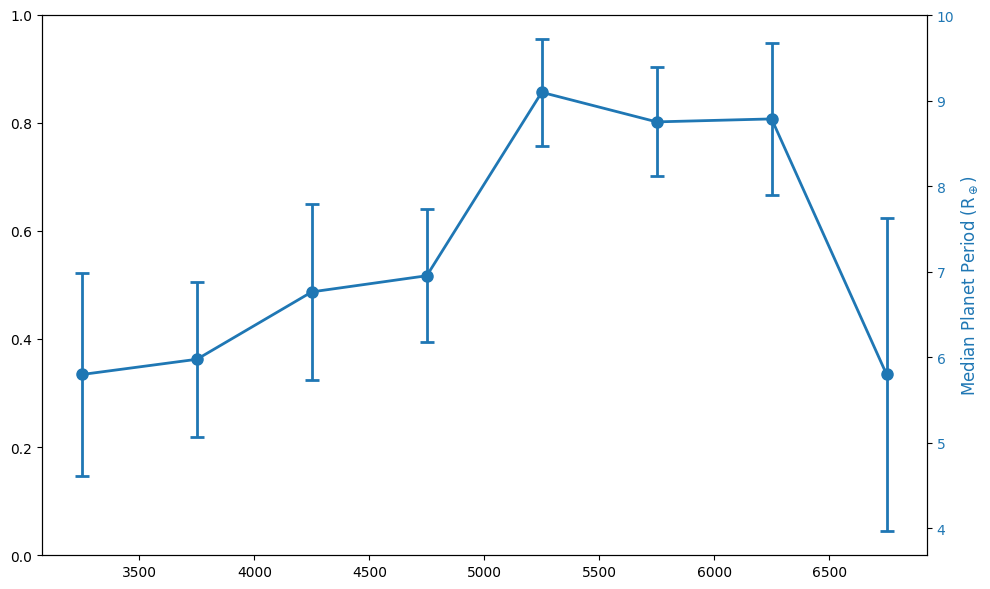

,Teff_bin_K,n_planets,planet_periods_days
0,3000-3500,69,"[425.4507, 0.3053, 40.3834, 2.6881, 12.8901, 3..."
1,3500-4000,120,"[1.9171, 4.0785, 3.3025, 16.8267, 2.0247, 2.21..."
2,4000-4500,120,"[5.0066, 19.4723, 6.6153, 5.9214, 2.0542, 2.08..."
3,4500-5000,145,"[3.5775, 5.322, 3.3928, 2.5604, 16.9357, 6.487..."
4,5000-5500,225,"[17.384, 12.3028, 748.7146, 12.9256, 26.0179, ..."
5,5500-6000,301,"[7.1887, 0.7313, 4.2404, 5.2169, 3.2608, 1.197..."
6,6000-6500,176,"[28.0694, 7.4903, 12.576, 4.0611, 31.1572, 6.8..."
7,6500-7000,36,"[16.2522, 1.2273, 1.5982, 5.1355, 14.2424, 4.9..."


In [10]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
print(TOIs.columns)
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Calculate errors for each bin using bootstrapping
planet_period_errors = []
planet_period_medians = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    #print(len(TOIs))
    TOIs_bin = TOIs.loc[bin_mask].dropna(subset=['pl_orbper'])
    #print(len(TOIs_bin))
    #print(len(TOIs))
    #print(TOIs['pl_orbper'])
    planet_period = TOIs_bin['pl_orbper']
    #print((planet_period))

    
    planet_period_n = len(planet_period)
    planet_median = np.nanmedian(planet_period)
    print(planet_median)
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_period.sample(n=planet_period_n, replace=True)
        bootstrap_medians.append(np.nanmedian(bootstrap_sample))
    
    planet_period_error = np.std(bootstrap_medians)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_n}")
    print(f"Planet period error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_error:.2f}")

    planet_period_median = np.median(planet_period)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_median:.2f} R_Earth")
    
    planet_period_medians.append(planet_period_median)
    planet_period_errors.append(planet_period_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(len(planet_period_medians), len(planet_period_errors), len(bin_centers))

# Plot stellar mass on primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))


# Create secondary y-axis for median planet radius with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_period_medians, yerr=planet_period_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='tab:blue')
ax2.set_ylabel('Median Planet Period (R$_\oplus$)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
#ax2.set_ylim(1.5,3.5)

plt.tight_layout()
plt.show()


# Create a table of planet periods by stellar temperature bin
rows = []
for i in range(len(bins_teff) - 1):
    lo, hi = bins_teff[i], bins_teff[i + 1]
    bin_periods = TOIs.loc[
        (TOIs["st_teff"] >= lo) & (TOIs["st_teff"] < hi),
        "pl_orbper"
    ].dropna()

    rows.append({
        "Teff_bin_K": f"{lo}-{hi}",
        "n_planets": len(bin_periods),
        "planet_periods_days": np.round(bin_periods.values, 4).tolist()
    })

periods_by_teff_table = pd.DataFrame(rows)
display(periods_by_teff_table)


Index(['toi', 'id', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra',
       'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1',
       'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1',
       'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1',
       'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1',
       'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2',
       'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim',
       'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist',
       'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1',
       'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2',
       'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim',
       'toi_created', 'rowupdat

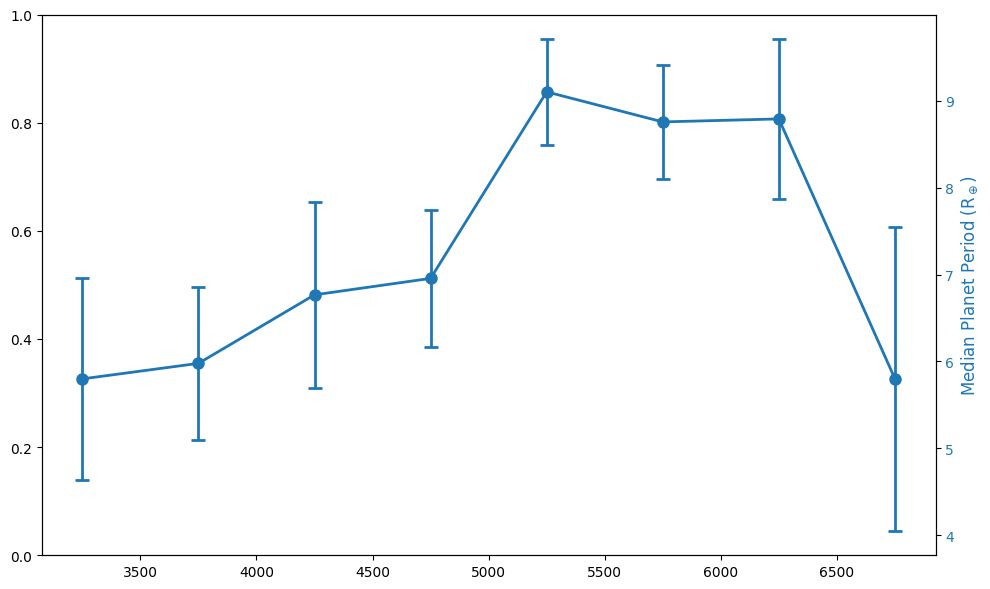

In [4]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
print(TOIs.columns)
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Calculate errors for each bin using bootstrapping
planet_period_errors = []
planet_period_medians = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    #print(len(TOIs))
    TOIs_bin = TOIs.loc[bin_mask].dropna(subset=['pl_orbper'])
    #print(len(TOIs_bin))
    #print(len(TOIs))
    #print(TOIs['pl_orbper'])
    planet_period = TOIs_bin['pl_orbper']
    #print((planet_period))

    
    planet_period_n = len(planet_period)
    planet_median = np.nanmedian(planet_period)
    print(planet_median)
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_period.sample(n=planet_period_n, replace=True)
        bootstrap_medians.append(np.nanmedian(bootstrap_sample))
    
    planet_period_error = np.std(bootstrap_medians)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_n}")
    print(f"Planet period error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_error:.2f}")

    planet_period_median = np.median(planet_period)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_median:.2f} R_Earth")
    
    planet_period_medians.append(planet_period_median)
    planet_period_errors.append(planet_period_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(len(planet_period_medians), len(planet_period_errors), len(bin_centers))

# Plot stellar mass on primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))


# Create secondary y-axis for median planet radius with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_period_medians, yerr=planet_period_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='tab:blue')
ax2.set_ylabel('Median Planet Period (R$_\oplus$)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
#ax2.set_ylim(1.5,3.5)

plt.tight_layout()
plt.show()


1837.8897313


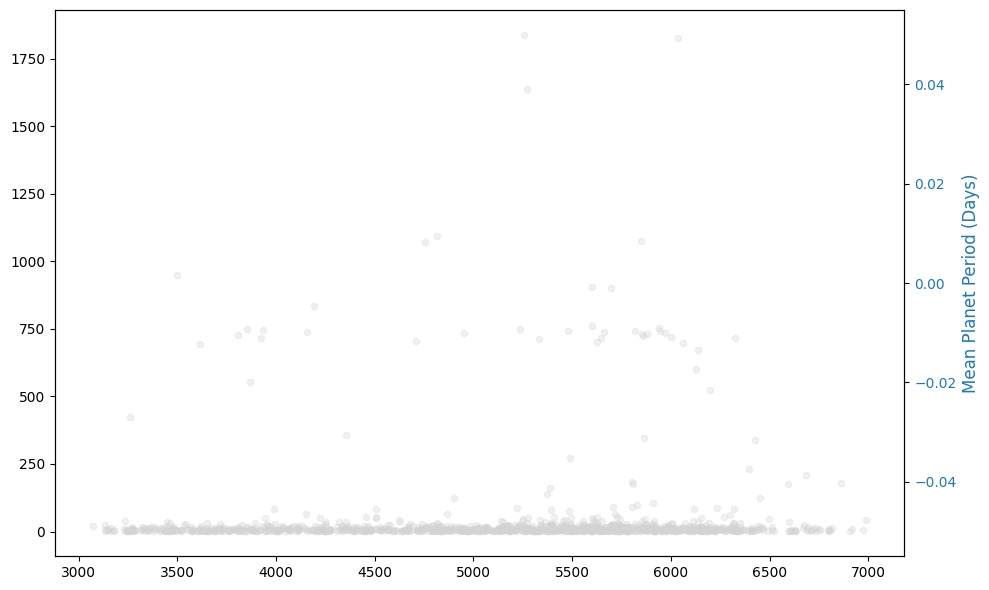

In [5]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Calculate errors for each bin using bootstrapping
planet_period_errors = []
planet_period_means = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    #print(len(TOIs))
    TOIs_bin = TOIs.loc[bin_mask].dropna(subset=['pl_orbper'])
    #print(len(TOIs_bin))
    #print(len(TOIs))
    #print(TOIs['pl_orbper'])
    planet_period = TOIs_bin['pl_orbper']
    #print((planet_period))

    
    planet_period_n = len(planet_period)
    planet_mean = np.nanmean(planet_period)
    #print(planet_mean)
    
    # # Bootstrap resampling
    # bootstrap_means = []
    # for _ in range(n_bootstrap):
    #     bootstrap_sample = planet_period.sample(n=planet_period_n, replace=True)
    
    # planet_period_error = np.std(bootstrap_means)
    # print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_n}")
    # print(f"Planet period error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_period_error:.2f}")

    # planet_period_median = np.median(planet_period)
    # print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_mean:.2f} R_Earth")
    
    # planet_period_means.append(planet_period_median)
    # planet_period_errors.append(planet_period_error)
    # bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
    
#print(len(planet_period_means), len(planet_period_errors), len(bin_centers))

# Plot stellar mass on primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot individual planet periods as background points
#TOIs_clean = TOIs.dropna(subset=['pl_orbper', 'st_teff'])
print(max(TOIs['pl_orbper']))
ax1.scatter(TOIs['st_teff'], TOIs['pl_orbper'], 
            alpha=0.3, s=20, color='lightgray', label='Individual planets')


# Create secondary y-axis for median planet radius with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_period_means, yerr=planet_period_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='tab:blue')
ax2.set_ylabel('Mean Planet Period (Days)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
#ax2.set_ylim(1.5,3.5)

plt.tight_layout()
plt.show()


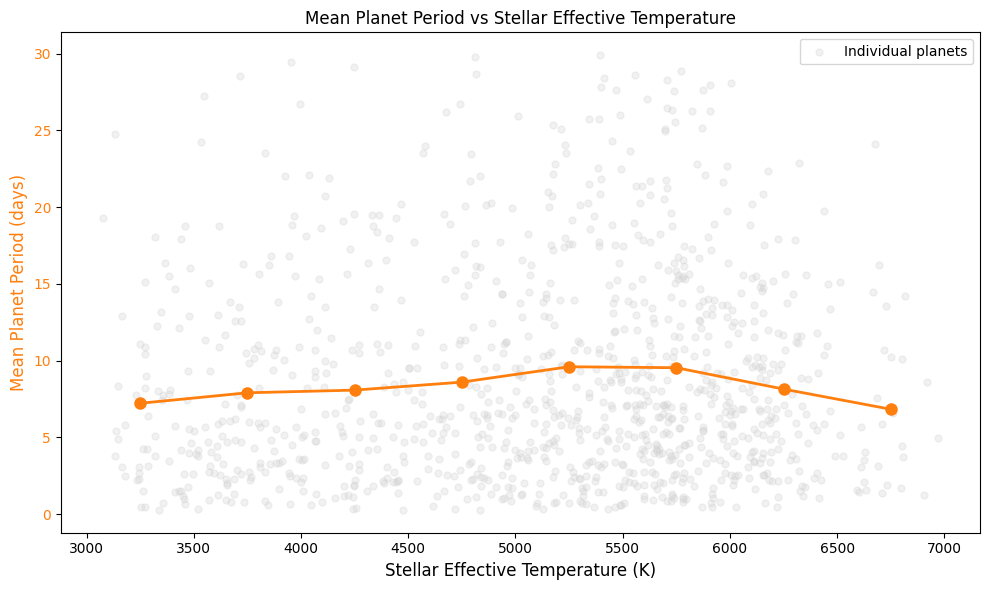

In [6]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]
TOIs = TOIs[TOIs['pl_orbper'] < 30]
# Calculate errors for each bin using bootstrapping
planet_period_errors = []
planet_period_means = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    #print(len(TOIs))
    TOIs_bin = TOIs.loc[bin_mask].dropna(subset=['pl_orbper'])
    #print(len(TOIs_bin))
    #print(len(TOIs))
    #print(TOIs['pl_orbper'])
    planet_period = TOIs_bin['pl_orbper']
    #print((planet_period))

    
    planet_period_n = len(planet_period)
    planet_mean = np.nanmean(planet_period)

    planet_period_means.append(planet_mean)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

# After the loop, plot the mean planet period per temperature bin (no error bars)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bin_centers, planet_period_means, marker='o', markersize=8, linewidth=2, color='tab:orange')
ax.set_xlabel('Stellar Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Mean Planet Period (days)', fontsize=12, color='tab:orange')
ax.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title('Mean Planet Period vs Stellar Effective Temperature')

ax.scatter(TOIs['st_teff'], TOIs['pl_orbper'], 
           alpha=0.3, s=25, color='lightgray', label='Individual planets')
ax.legend(loc='best')
plt.tight_layout()
plt.show()



0.568162925
Number of planets in 3000-3500 K bin: 4
Planet insolation error in 3000-3500 K bin: 0.17
Mean planet insolation in 3000-3500 K bin: 0.57 S_Earth
0.7778000636363636
Number of planets in 3500-4000 K bin: 11
Planet insolation error in 3500-4000 K bin: 0.26
Mean planet insolation in 3500-4000 K bin: 0.78 S_Earth
2.1622745666666665
Number of planets in 4000-4500 K bin: 9
Planet insolation error in 4000-4500 K bin: 0.50
Mean planet insolation in 4000-4500 K bin: 2.16 S_Earth
3.5451623999999997
Number of planets in 4500-5000 K bin: 11
Planet insolation error in 4500-5000 K bin: 1.01
Mean planet insolation in 4500-5000 K bin: 3.55 S_Earth
10.71336696521739
Number of planets in 5000-5500 K bin: 23
Planet insolation error in 5000-5500 K bin: 3.17
Mean planet insolation in 5000-5500 K bin: 10.71 S_Earth
18.736172697058823
Number of planets in 5500-6000 K bin: 34
Planet insolation error in 5500-6000 K bin: 9.11
Mean planet insolation in 5500-6000 K bin: 18.74 S_Earth
20.406976896
Numbe

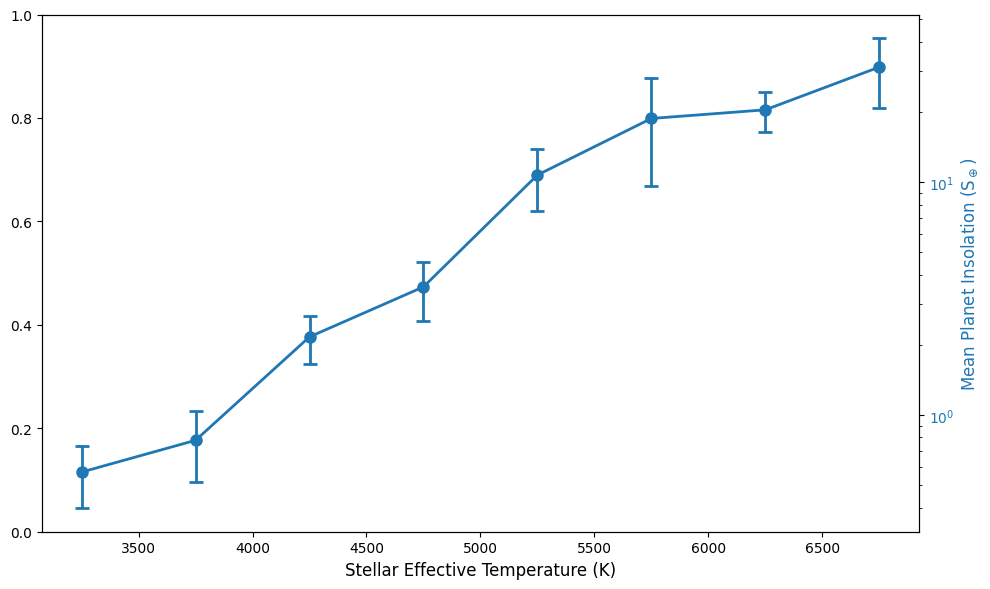

In [7]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]
TOIs = TOIs[TOIs['pl_orbper'] > 30]
# Calculate errors for each bin using bootstrapping
planet_insol_errors = []
planet_insol_means = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    TOIs_bin = TOIs.loc[bin_mask].dropna(subset=['pl_insol'])
    planet_insol = TOIs_bin['pl_insol']
    
    planet_insol_n = len(planet_insol)
    planet_mean = np.nanmean(planet_insol)
    print(planet_mean)
    
    # Bootstrap resampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_insol.sample(n=planet_insol_n, replace=True)
        bootstrap_means.append(np.nanmean(bootstrap_sample))
    
    planet_insol_error = np.std(bootstrap_means)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_insol_n}")
    print(f"Planet insolation error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_insol_error:.2f}")

    planet_insol_mean = np.mean(planet_insol)
    print(f"Mean planet insolation in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_mean:.2f} S_Earth")
    
    planet_insol_means.append(planet_insol_mean)
    planet_insol_errors.append(planet_insol_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
    
print(len(planet_insol_means), len(planet_insol_errors), len(bin_centers))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Create secondary y-axis for mean planet insolation with error bars
ax2 = ax1.twinx()
ax2.set_yscale('log')

# # Plot individual planets as background dots
# TOIs_clean = TOIs.dropna(subset=['pl_insol', 'st_teff'])
# ax2.scatter(TOIs_clean['st_teff'], TOIs_clean['pl_insol'], 
#            alpha=0.3, s=20, color='lightgray', zorder=1)

# Plot mean with error bars on top
ax2.errorbar(bin_centers, planet_insol_means, yerr=planet_insol_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, 
             color='tab:blue', zorder=2)

ax2.set_ylabel('Mean Planet Insolation (S$_\oplus$)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlabel('Stellar Effective Temperature (K)', fontsize=12)

plt.tight_layout()
plt.show()


3000-3500 K: 70 planets, median radius = 2.06 R⊕
3500-4000 K: 121 planets, median radius = 2.27 R⊕
4000-4500 K: 122 planets, median radius = 2.59 R⊕
4500-5000 K: 149 planets, median radius = 2.61 R⊕
5000-5500 K: 232 planets, median radius = 2.64 R⊕
5500-6000 K: 309 planets, median radius = 2.63 R⊕
6000-6500 K: 183 planets, median radius = 2.69 R⊕
6500-7000 K: 38 planets, median radius = 2.97 R⊕


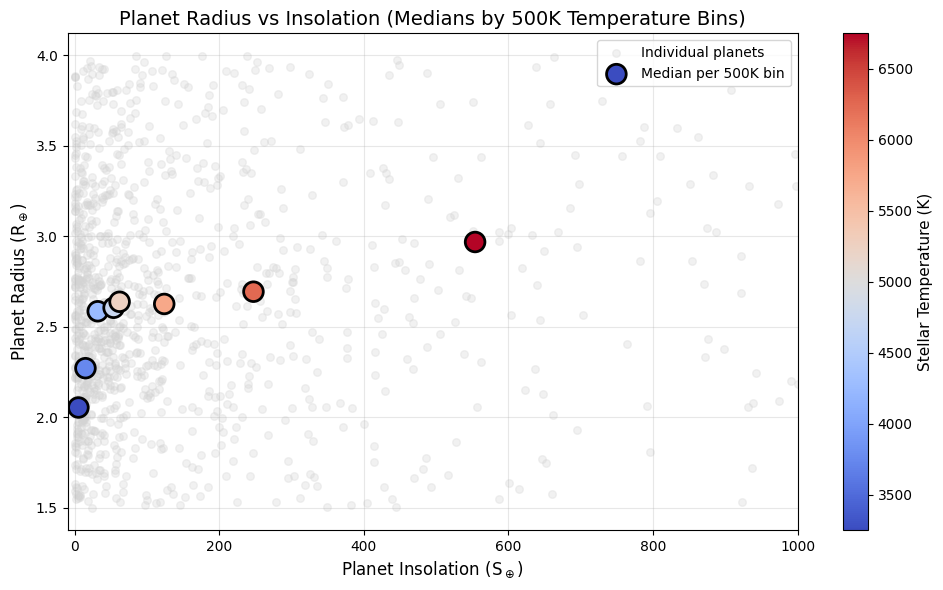


Total number of planets plotted: 1224


In [8]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")

# Clean data - remove NaN values
TOIs_clean = TOIs.dropna(subset=['pl_rade', 'pl_insol', 'st_teff'])

# Define temperature bins (500K intervals)
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Calculate median planet radius for each temperature bin
median_radii = []
median_insol = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs_clean['st_teff'] >= bins_teff[i]) & (TOIs_clean['st_teff'] < bins_teff[i+1])
    TOIs_bin = TOIs_clean[bin_mask]
    
    if len(TOIs_bin) > 0:
        median_radii.append(np.median(TOIs_bin['pl_rade']))
        median_insol.append(np.median(TOIs_bin['pl_insol']))
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        print(f"{bins_teff[i]}-{bins_teff[i+1]} K: {len(TOIs_bin)} planets, median radius = {median_radii[-1]:.2f} R⊕")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual planets as background
ax.scatter(TOIs_clean['pl_insol'], TOIs_clean['pl_rade'], 
           alpha=0.3, s=30, color='lightgray', label='Individual planets')

# Plot median values for each temperature bin
scatter = ax.scatter(median_insol, median_radii, 
                     c=bin_centers, s=200, cmap='coolwarm', 
                     edgecolors='black', linewidths=2, 
                     label='Median per 500K bin', zorder=5)

# Add colorbar for temperature
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Stellar Temperature (K)', fontsize=11)

ax.set_xlabel('Planet Insolation (S$_\oplus$)', fontsize=12)
ax.set_ylabel('Planet Radius (R$_\oplus$)', fontsize=12)
ax.set_title('Planet Radius vs Insolation (Medians by 500K Temperature Bins)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
ax.set_xlim(-10,1000)

plt.tight_layout()
plt.show()

print(f"\nTotal number of planets plotted: {len(TOIs_clean)}")